In [1]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

In [2]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

In [3]:
mlps_models = [mlps_dic[mode_label]['model'] for mode_label in mode_labels]

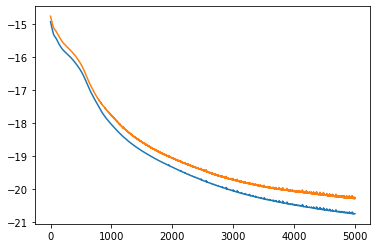

In [4]:
plt.plot(flows_dic[0]['losses'][0])
plt.plot(flows_dic[0]['losses'][1])

In [5]:
weights = torch.tensor([0.5, 0.5])
mixture = Mixture(get_models(flows_dic), weights)

In [6]:
mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']
coord_mapping = Coordinates_mapping()

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 12],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 13])
    x = join_data(x, logdetjac, energies, zmat[:, 14])
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)

In [22]:
import time

times = []
n_chainss = np.logspace(1, 6, 8).astype(int)
for n_chains in n_chainss:
    x_u_is_init = xs[:n_chains, :]
    # x_u_is_init[:, 14] 
    # x_u_is_init.shape
    start = time.time()
    mcmc_run = run_metropolis(mixture, init=x_u_is_init, n_chains=x_u_is_init.shape[0], n_steps=10, mixture=True, mlp_models=mlps_models, energy_type='mlp', with_tqdm=True)
    times.append(time.time() - start)

acc: 0.20: 100%|██████████| 10/10 [00:47<00:00,  4.75s/it]


Text(0, 0.5, 'Time/10 MH it (s)')

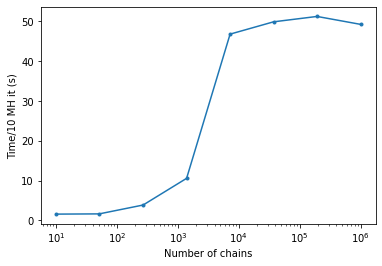

In [23]:
plt.figure()
plt.plot(n_chainss, times, '.-')
plt.xscale('log')
plt.xlabel('Number of chains')
plt.ylabel('Time/10 MH it (s)')